# IT2011 – Breast Cancer Wisconsin (Original)

## Member 03 – Target Encoding, Outlier Analysis & Feature Selection

**Dataset:** Breast Cancer Wisconsin (Original)  
**Course:** IT2011 – Artificial Intelligence and Machine Learning  
**Main Responsibilities:**
- Target/Class Encoding
- Outlier Investigation
- Outlier Handling Decision
- Feature Selection using ANOVA F-test
- Feature Selection Visualization
- Interpretation of Results

In [3]:
%pip install scikit-learn

   ---------------------------------------- 0.0/8.4 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.4 MB 3.2 MB/s eta 0:00:03
   ----- ---------------------------------- 1.0/8.4 MB 3.2 MB/s eta 0:00:03
   -------- ------------------------------- 1.8/8.4 MB 3.4 MB/s eta 0:00:02
   ------------ --------------------------- 2.6/8.4 MB 3.4 MB/s eta 0:00:02
   ---------------- ----------------------- 3.4/8.4 MB 3.6 MB/s eta 0:00:02
   --------------------- ------------------ 4.5/8.4 MB 3.7 MB/s eta 0:00:02
   -------------------------- ------------- 5.5/8.4 MB 3.9 MB/s eta 0:00:01
   -------------------------------- ------- 6.8/8.4 MB 4.2 MB/s eta 0:00:01
   ------------------------------------- -- 7.9/8.4 MB 4.3 MB/s eta 0:00:01
   ---------------------------------------- 8.4/8.4 MB 4.3 MB/s  0:00:02
   ---------------------------------------- 0.0/37.4 MB ? eta -:--:--
    --------------------------------------- 0.8/37.4 MB 5.4 MB/s eta 0:00:07
   - ----------------------

In [5]:
# ============================================
# STEP 1.1 - Import required libraries
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import f_classif

print("Libraries imported successfully.")

Libraries imported successfully.


In [4]:
# ============================================
# STEP 2.1 - Load the raw dataset
# ============================================

file_path = "data/raw/breast-cancer-wisconsin.data"

df = pd.read_csv(file_path, header=None)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (699, 11)


In [6]:
# ============================================
# STEP 2.2 - Assign meaningful column names
# ============================================

columns = [
    "Sample_ID",
    "Clump_Thickness",
    "Uniformity_Cell_Size",
    "Uniformity_Cell_Shape",
    "Marginal_Adhesion",
    "Single_Epithelial_Cell_Size",
    "Bare_Nuclei",
    "Bland_Chromatin",
    "Normal_Nucleoli",
    "Mitoses",
    "Class"
]

df.columns = columns

print("Column names assigned successfully.")
display(df.head())

Column names assigned successfully.


,Sample_ID,Clump_Thickness,Uniformity_Cell_Size,Uniformity_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


In [7]:
# ============================================
# STEP 3.1 - Convert missing value markers to NaN
# ============================================

df = df.replace("?", np.nan)

print("Missing values after replacing '?' with NaN:")
print(df.isnull().sum())

Missing values after replacing '?' with NaN:
Sample_ID                       0
Clump_Thickness                 0
Uniformity_Cell_Size            0
Uniformity_Cell_Shape           0
Marginal_Adhesion               0
Single_Epithelial_Cell_Size     0
Bare_Nuclei                    16
Bland_Chromatin                 0
Normal_Nucleoli                 0
Mitoses                         0
Class                           0
dtype: int64


In [8]:
# ============================================
# STEP 4.1 - Define the nine predictive features
# ============================================

feature_columns = [
    "Clump_Thickness",
    "Uniformity_Cell_Size",
    "Uniformity_Cell_Shape",
    "Marginal_Adhesion",
    "Single_Epithelial_Cell_Size",
    "Bare_Nuclei",
    "Bland_Chromatin",
    "Normal_Nucleoli",
    "Mitoses"
]

print("Number of predictive features:", len(feature_columns))
print("\nPredictive features:")
for feature in feature_columns:
    print("-", feature)

Number of predictive features: 9

Predictive features:
- Clump_Thickness
- Uniformity_Cell_Size
- Uniformity_Cell_Shape
- Marginal_Adhesion
- Single_Epithelial_Cell_Size
- Bare_Nuclei
- Bland_Chromatin
- Normal_Nucleoli
- Mitoses


In [9]:
# ============================================
# STEP 5.1 - Examine the original class labels
# ============================================

print("Original class values:")
print(df["Class"].value_counts().sort_index())

Original class values:
Class
2    458
4    241
Name: count, dtype: int64


In [10]:
# ============================================
# STEP 5.1 - Examine the original class labels
# ============================================

print("Original class values:")
print(df["Class"].value_counts().sort_index())

Original class values:
Class
2    458
4    241
Name: count, dtype: int64


In [11]:
# ============================================
# STEP 6.1 - Check the valid range of feature values
# ============================================

feature_range = pd.DataFrame({
    "Minimum": df[feature_columns].min(),
    "Maximum": df[feature_columns].max()
})

display(feature_range)

,Minimum,Maximum
Clump_Thickness,1,10
Uniformity_Cell_Size,1,10
Uniformity_Cell_Shape,1,10
Marginal_Adhesion,1,10
Single_Epithelial_Cell_Size,1,10
Bare_Nuclei,1,9
Bland_Chromatin,1,10
Normal_Nucleoli,1,10
Mitoses,1,10


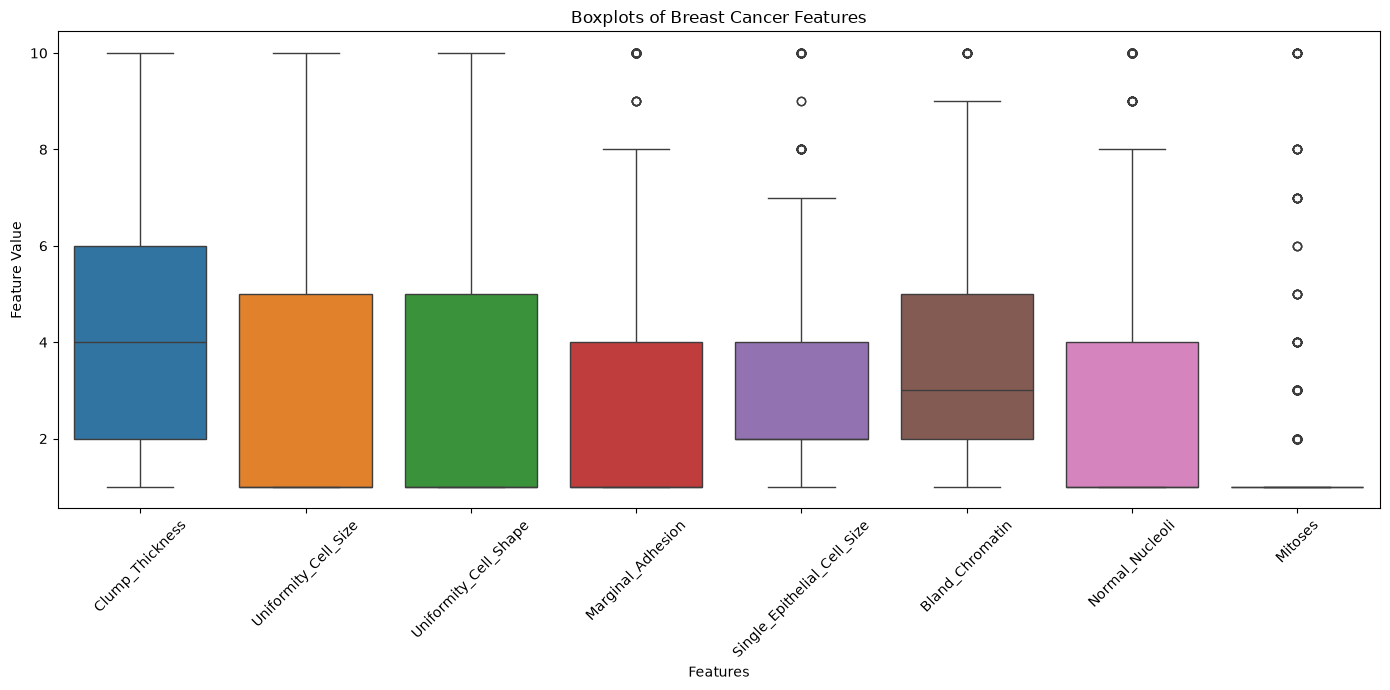

In [12]:
# ============================================
# STEP 6.2 - Visualize potential statistical outliers
# ============================================

plt.figure(figsize=(14, 7))

sns.boxplot(data=df[feature_columns])

plt.title("Boxplots of Breast Cancer Features")
plt.xlabel("Features")
plt.ylabel("Feature Value")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [14]:
# ============================================
# STEP 6.3 - Calculate statistical outliers using IQR
# ============================================

# Automatically filter feature_columns to include numeric types only
numeric_features = df[feature_columns].select_dtypes(include=['number']).columns

outlier_results = []

for feature in numeric_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[feature] < lower_bound) |
        (df[feature] > upper_bound)
    ][feature].count()

    outlier_results.append({
        "Feature": feature,
        "Q1": Q1,
        "Q3": Q3,
        "Outliers": outliers
    })

## Outlier Handling Decision

The boxplots and IQR analysis identified statistical outliers in several
features.

However, these observations were not automatically removed.

The predictive features in this dataset use a valid scoring range from
1 to 10. Therefore, a statistically unusual value does not necessarily
mean that the observation is incorrect.

In a medical dataset, unusual measurements may contain useful information
about differences between benign and malignant cases.

Therefore, the decision was to:

- Investigate statistical outliers.
- Confirm that feature values remain within the valid 1–10 range.
- Retain valid observations.
- Avoid removing observations only because they are statistical outliers.

This prevents potentially useful medical information from being removed.

In [16]:
# ============================================
# STEP 8.1 - Prepare features and target for feature selection
# ============================================

# Define target column (replace 'Class' with your actual target column name)
y = df['Class'].copy()

# Prepare feature matrix
X = df[feature_columns].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (699, 9)
Target shape: (699,)


In [17]:
# ============================================
# STEP 9.1 - Prepare complete cases for ANOVA
# ============================================

anova_data = pd.concat([X, y.rename("Target")], axis=1)

anova_data = anova_data.dropna()

X_anova = anova_data[feature_columns]
y_anova = anova_data["Target"]

print("Original observations:", len(X))
print("Observations used for ANOVA:", len(X_anova))
print("Observations excluded due to missing values:", len(X) - len(X_anova))

Original observations: 699
Observations used for ANOVA: 683
Observations excluded due to missing values: 16


In [18]:
# ============================================
# STEP 10.1 - Perform ANOVA F-test for feature selection
# ============================================

f_scores, p_values = f_classif(X_anova, y_anova)

feature_selection_results = pd.DataFrame({
    "Feature": feature_columns,
    "F_Score": f_scores,
    "P_Value": p_values
})

feature_selection_results = feature_selection_results.sort_values(
    by="F_Score",
    ascending=False
).reset_index(drop=True)

display(feature_selection_results)

,Feature,F_Score,P_Value
0,Bare_Nuclei,1426.240270,3.401103e-169
1,Uniformity_Cell_Shape,1417.643841,1.369425e-168
2,Uniformity_Cell_Size,1406.132470,8.922226e-168
3,Bland_Chromatin,921.010015,1.267712e-128
4,Normal_Nucleoli,727.470805,1.465645e-109
5,Clump_Thickness,711.423446,7.292504e-108
6,Marginal_Adhesion,677.878400,2.979778e-104
7,Single_Epithelial_Cell_Size,622.157681,4.733540e-98
8,Mitoses,148.787689,4.304040e-31


In [19]:
# ============================================
# STEP 11.1 - Identify statistically significant features
# ============================================

alpha = 0.05

feature_selection_results["Significant"] = (
    feature_selection_results["P_Value"] < alpha
)

display(feature_selection_results)

,Feature,F_Score,P_Value,Significant
0,Bare_Nuclei,1426.240270,3.401103e-169,True
1,Uniformity_Cell_Shape,1417.643841,1.369425e-168,True
2,Uniformity_Cell_Size,1406.132470,8.922226e-168,True
3,Bland_Chromatin,921.010015,1.267712e-128,True
4,Normal_Nucleoli,727.470805,1.465645e-109,True
5,Clump_Thickness,711.423446,7.292504e-108,True
6,Marginal_Adhesion,677.878400,2.979778e-104,True
7,Single_Epithelial_Cell_Size,622.157681,4.733540e-98,True
8,Mitoses,148.787689,4.304040e-31,True


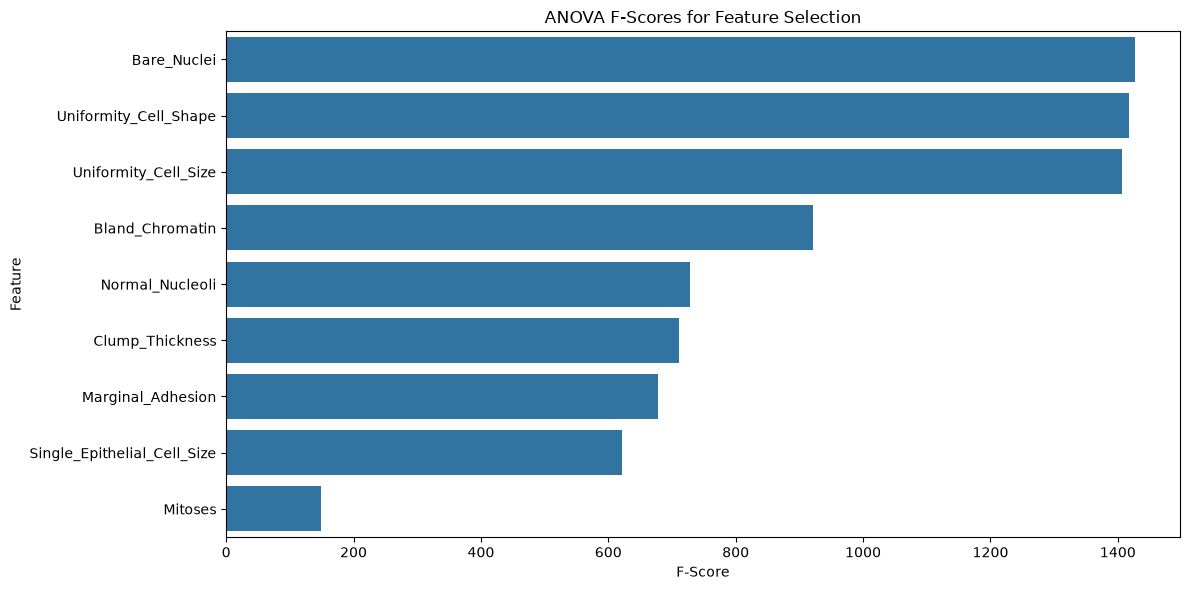

In [20]:
# ============================================
# STEP 12.1 - Visualize ANOVA F-scores
# ============================================

plt.figure(figsize=(12, 6))

sns.barplot(
    data=feature_selection_results,
    x="F_Score",
    y="Feature"
)

plt.title("ANOVA F-Scores for Feature Selection")
plt.xlabel("F-Score")
plt.ylabel("Feature")
plt.tight_layout()

plt.show()

In [21]:
# ============================================
# STEP 13.1 - Select statistically significant features
# ============================================

selected_features = feature_selection_results[
    feature_selection_results["P_Value"] < 0.05
]["Feature"].tolist()

print("Selected features:")
for feature in selected_features:
    print("-", feature)

print("\nNumber of selected features:", len(selected_features))

Selected features:
- Bare_Nuclei
- Uniformity_Cell_Shape
- Uniformity_Cell_Size
- Bland_Chromatin
- Normal_Nucleoli
- Clump_Thickness
- Marginal_Adhesion
- Single_Epithelial_Cell_Size
- Mitoses

Number of selected features: 9


## Feature Selection Summary

ANOVA F-test was used to investigate whether each predictive feature
showed a statistically significant difference between the two target
classes.

The significance level was set to 0.05.

All nine predictive features produced p-values below 0.05.

Therefore:

- All nine features were retained.
- No feature was removed using the ANOVA significance criterion.
- Uniformity_Cell_Size had the highest F-score.
- Uniformity_Cell_Shape and Bare_Nuclei also showed very high F-scores.
- Mitoses had the lowest F-score, but it was still statistically significant.

Therefore, Mitoses was also retained.

In [22]:
# ============================================
# STEP 15.1 - Save feature selection results
# ============================================

output_path = "results/outputs/feature_selection_anova.csv"

feature_selection_results.to_csv(
    output_path,
    index=False
)

print("Feature selection results saved to:")
print(output_path)

Feature selection results saved to:
results/outputs/feature_selection_anova.csv


In [26]:
# ============================================
# STEP 16.1 - Save outlier analysis results
# ============================================

# Convert the list of outlier results into a DataFrame
outlier_df = pd.DataFrame(outlier_results)

# Save to CSV
outlier_output_path = "results/outputs/outlier_analysis.csv"

outlier_df.to_csv(
    outlier_output_path,
    index=False
)

print("Outlier analysis results saved to:")
print(outlier_output_path)

Outlier analysis results saved to:
results/outputs/outlier_analysis.csv


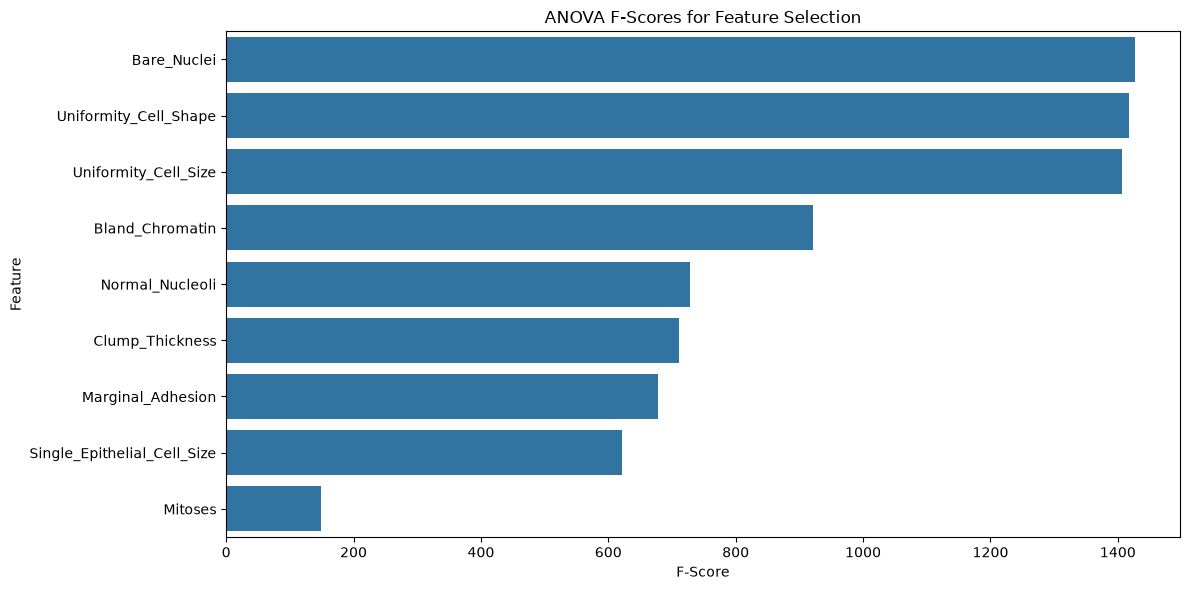

ANOVA plot saved to:
results/eda_visualizations/anova_f_scores.png


In [25]:
# ============================================
# STEP 17.1 - Save the ANOVA visualization
# ============================================

anova_plot_path = "results/eda_visualizations/anova_f_scores.png"

plt.figure(figsize=(12, 6))

sns.barplot(
    data=feature_selection_results,
    x="F_Score",
    y="Feature"
)

plt.title("ANOVA F-Scores for Feature Selection")
plt.xlabel("F-Score")
plt.ylabel("Feature")
plt.tight_layout()

plt.savefig(anova_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("ANOVA plot saved to:")
print(anova_plot_path)

# Member 3 Final Summary

## Target Encoding
The original target labels were:

- 2 = Benign
- 4 = Malignant

They were encoded as:

- 0 = Benign
- 1 = Malignant

## Outlier Analysis
Statistical outliers were identified using boxplots and the IQR method.

However, the feature values are within the valid 1–10 scoring range.
Therefore, valid statistical outliers were retained instead of being
automatically removed.

## Feature Selection
ANOVA F-test was used with a significance level of 0.05.

All nine predictive features had statistically significant p-values
below 0.05.

Therefore, all nine features were retained.

## Main Conclusion
The dataset contains potentially useful information across all nine
predictive features. No feature was removed using the ANOVA significance
criterion, while PCA was later used separately for dimensionality
reduction.